In [1]:
import sys
import tensorflow as tf

print(f"Python      : {sys.version.split()[0]}")
print(f"TensorFlow  : {tf.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

Python      : 3.13.15
TensorFlow  : 2.20.0
GPU devices : []


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

DATA_PATH = Path("/content/Cleaned_Data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Upload Cleaned_Data.csv to the Colab session first."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (99342, 20)


,Unnamed: 0,index,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews
0,0,0,Clean & quiet apt home by the park,80014485718,UNCONFIRMED,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,0,strict,Private room,2020.0,966,$193,10.0,9.0
1,1,1,Skylit Midtown Castle,52335172823,VERIFIED,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,0,moderate,Entire home/apt,2007.0,142,$28,30.0,45.0
2,2,4,Entire Apt: Spacious Studio/Loft by central park,92037596077,VERIFIED,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,0,moderate,Entire home/apt,2009.0,204,$41,10.0,9.0
3,3,5,Large Cozy 1 BR Apartment In Midtown East,45498551794,VERIFIED,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,1,flexible,Entire home/apt,2013.0,577,$115,3.0,74.0
4,4,7,BlissArtsSpace!,90821839709,UNCONFIRMED,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,0,moderate,Private room,2009.0,1060,$212,45.0,49.0


In [4]:
features = [
    'host_identity_verified',
    'neighbourhood group',
    'neighbourhood',
    'lat',
    'long',
    'instant_bookable',
    'cancellation_policy',
    'room type',
    'Construction year',
    'minimum nights',
    'number of reviews'
]

target = 'price'

In [5]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42
    test_size: float = 0.20
    validation_size: float = 0.10


CFG = ExperimentConfig()

np.random.seed(CFG.seed)
tf.keras.utils.set_random_seed(CFG.seed)

In [6]:
FEATURES = [
    "host_identity_verified",
    "neighbourhood group",
    "neighbourhood",
    "lat",
    "long",
    "instant_bookable",
    "cancellation_policy",
    "room type",
    "Construction year",
    "minimum nights",
    "number of reviews",
]

TARGET = "price"

X = df.loc[:, FEATURES].copy()
y = df.loc[:, TARGET].astype(np.float32)

print(f"Feature matrix : {X.shape}")
print(f"Target vector  : {y.shape}")

Feature matrix : (99342, 11)
Target vector  : (99342,)


In [7]:
CATEGORICAL_FEATURES = [
    "host_identity_verified",
    "neighbourhood group",
    "neighbourhood",
    "cancellation_policy",
    "room type",
]

NUMERICAL_FEATURES = [
    "lat",
    "long",
    "instant_bookable",
    "Construction year",
    "minimum nights",
    "number of reviews",
]

assert set(CATEGORICAL_FEATURES + NUMERICAL_FEATURES) == set(FEATURES)

In [8]:
def validate_inputs(features: pd.DataFrame, target: pd.Series) -> None:
    if features.isna().any().any():
        raise ValueError("Feature matrix contains missing values.")

    if target.isna().any():
        raise ValueError("Target vector contains missing values.")

    numeric_block = features.select_dtypes(include=np.number)

    if not np.isfinite(numeric_block.to_numpy()).all():
        raise ValueError("Numerical features contain non-finite values.")

    if not np.isfinite(target.to_numpy()).all():
        raise ValueError("Target contains non-finite values.")


validate_inputs(X, y)

print("Input validation passed.")

Input validation passed.


In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=CFG.test_size,
    random_state=CFG.seed,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=CFG.validation_size,
    random_state=CFG.seed,
)

print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")

Training   : (71525, 11)
Validation : (7948, 11)
Test       : (19869, 11)


In [10]:
numeric_pipeline = StandardScaler()

categorical_pipeline = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERICAL_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [12]:
X_train_processed = np.asarray(X_train_processed, dtype=np.float32)
X_val_processed = np.asarray(X_val_processed, dtype=np.float32)
X_test_processed = np.asarray(X_test_processed, dtype=np.float32)

y_train = y_train.to_numpy(dtype=np.float32)
y_val = y_val.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32)

In [13]:
print(f"Processed training shape   : {X_train_processed.shape}")
print(f"Processed validation shape : {X_val_processed.shape}")
print(f"Processed test shape       : {X_test_processed.shape}")

print(f"\nTraining dtype : {X_train_processed.dtype}")
print(f"Target dtype   : {y_train.dtype}")

Processed training shape   : (71525, 245)
Processed validation shape : (7948, 245)
Processed test shape       : (19869, 245)

Training dtype : float32
Target dtype   : float32


In [14]:
assert X_train_processed.shape[1] == X_val_processed.shape[1]
assert X_train_processed.shape[1] == X_test_processed.shape[1]

assert X_train_processed.dtype == np.float32
assert X_val_processed.dtype == np.float32
assert X_test_processed.dtype == np.float32

assert np.isfinite(X_train_processed).all()
assert np.isfinite(X_val_processed).all()
assert np.isfinite(X_test_processed).all()

print("✓ Preprocessing pipeline validated successfully.")

✓ Preprocessing pipeline validated successfully.


In [15]:
from tensorflow import keras
from tensorflow.keras import layers


def build_regressor(
    input_dim: int,
    learning_rate: float = 1e-3,
) -> keras.Model:
    inputs = keras.Input(
        shape=(input_dim,),
        name="airbnb_features",
    )

    x = layers.Dense(
        256,
        kernel_initializer="he_normal",
        name="dense_256",
    )(inputs)
    x = layers.BatchNormalization(name="bn_256")(x)
    x = layers.Activation("relu", name="relu_256")(x)
    x = layers.Dropout(0.30, name="dropout_256")(x)

    x = layers.Dense(
        128,
        kernel_initializer="he_normal",
        name="dense_128",
    )(x)
    x = layers.BatchNormalization(name="bn_128")(x)
    x = layers.Activation("relu", name="relu_128")(x)
    x = layers.Dropout(0.25, name="dropout_128")(x)

    x = layers.Dense(
        64,
        kernel_initializer="he_normal",
        name="dense_64",
    )(x)
    x = layers.Activation("relu", name="relu_64")(x)
    x = layers.Dropout(0.20, name="dropout_64")(x)

    x = layers.Dense(
        32,
        kernel_initializer="he_normal",
        name="dense_32",
    )(x)
    x = layers.Activation("relu", name="relu_32")(x)

    outputs = layers.Dense(
        1,
        name="price_prediction",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="airbnb_price_regressor",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=keras.losses.MeanSquaredError(),
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )

    return model


model = build_regressor(
    input_dim=X_train_processed.shape[1],
    learning_rate=1e-3,
)

model.summary()

Model: "airbnb_price_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ airbnb_features (InputLayer)    │ (None, 245)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        62,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_256 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_256 (Activation)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_128 (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_prediction (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,777 (421.00 KB)

 Trainable params: 107,009 (418.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [16]:
print(f"Model name       : {model.name}")
print(f"Input dimensions : {model.input_shape[-1]}")
print(f"Output dimensions: {model.output_shape[-1]}")
print(f"Trainable params : {model.count_params():,}")

Model name       : airbnb_price_regressor
Input dimensions : 245
Output dimensions: 1
Trainable params : 107,777


In [17]:
from pathlib import Path

from tensorflow.keras import callbacks


CHECKPOINT_DIR = Path("/content/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_airbnb_price_regressor.keras"


training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_delta=1e-3,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
]

print("Training callbacks configured:")
for callback in training_callbacks:
    print(f"  • {callback.__class__.__name__}")

Training callbacks configured:
  • EarlyStopping
  • ReduceLROnPlateau
  • ModelCheckpoint


In [19]:
from dataclasses import dataclass

import numpy as np
import tensorflow as tf


@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42

    # Data partitioning
    test_size: float = 0.20
    validation_size: float = 0.10

    # Training
    batch_size: int = 128
    epochs: int = 30
    learning_rate: float = 1e-3


CFG = ExperimentConfig()

np.random.seed(CFG.seed)
tf.keras.utils.set_random_seed(CFG.seed)

print("Experiment configuration")
print("-" * 30)
print(f"Seed            : {CFG.seed}")
print(f"Test size       : {CFG.test_size:.0%}")
print(f"Validation size : {CFG.validation_size:.0%}")
print(f"Batch size      : {CFG.batch_size}")
print(f"Maximum epochs  : {CFG.epochs}")
print(f"Learning rate   : {CFG.learning_rate}")

Experiment configuration
------------------------------
Seed            : 42
Test size       : 20%
Validation size : 10%
Batch size      : 128
Maximum epochs  : 30
Learning rate   : 0.001


In [20]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=CFG.epochs,
    batch_size=CFG.batch_size,
    callbacks=training_callbacks,
    verbose=1,
)

Epoch 1/30
554/559 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 259874.1041 - mae: 417.2994 - rmse: 500.7031
Epoch 1: val_loss improved from None to 111557.03906, saving model to /content/checkpoints/best_airbnb_price_regressor.keras

Epoch 1: finished saving model to /content/checkpoints/best_airbnb_price_regressor.keras
559/559 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 163977.3125 - mae: 333.7987 - rmse: 404.9411 - val_loss: 111557.0391 - val_mae: 287.8708 - val_rmse: 334.0016 - learning_rate: 0.0010
Epoch 2/30
557/559 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 115592.6195 - mae: 291.7455 - rmse: 339.9875
Epoch 2: val_loss improved from 111557.03906 to 110332.67188, saving model to /content/checkpoints/best_airbnb_price_regressor.keras

Epoch 2: finished saving model to /content/checkpoints/best_airbnb_price_regressor.keras
559/559 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 115232.9766 - mae: 291.1820 - rmse: 339.4598 - val_loss: 110332.6719 - val_mae: 286.8776 - val_rmse: 332.1636 - learning

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def extract_training_history(history):
    history_frame = pd.DataFrame(history.history)
    history_frame.insert(0, "epoch", np.arange(1, len(history_frame) + 1))
    return history_frame


history_df = extract_training_history(history)

best_epoch_idx = history_df["val_loss"].idxmin()
best_epoch = int(history_df.loc[best_epoch_idx, "epoch"])

print(f"Training epochs completed : {len(history_df)}")
print(f"Best validation epoch     : {best_epoch}")
print(
    f"Best validation loss      : "
    f"{history_df.loc[best_epoch_idx, 'val_loss']:,.4f}"
)
print(
    f"Best validation MAE       : "
    f"{history_df.loc[best_epoch_idx, 'val_mae']:,.4f}"
)
print(
    f"Best validation RMSE      : "
    f"{history_df.loc[best_epoch_idx, 'val_rmse']:,.4f}"
)

Training epochs completed : 10
Best validation epoch     : 4
Best validation loss      : 110,053.1484
Best validation MAE       : 286.5059
Best validation RMSE      : 331.7426


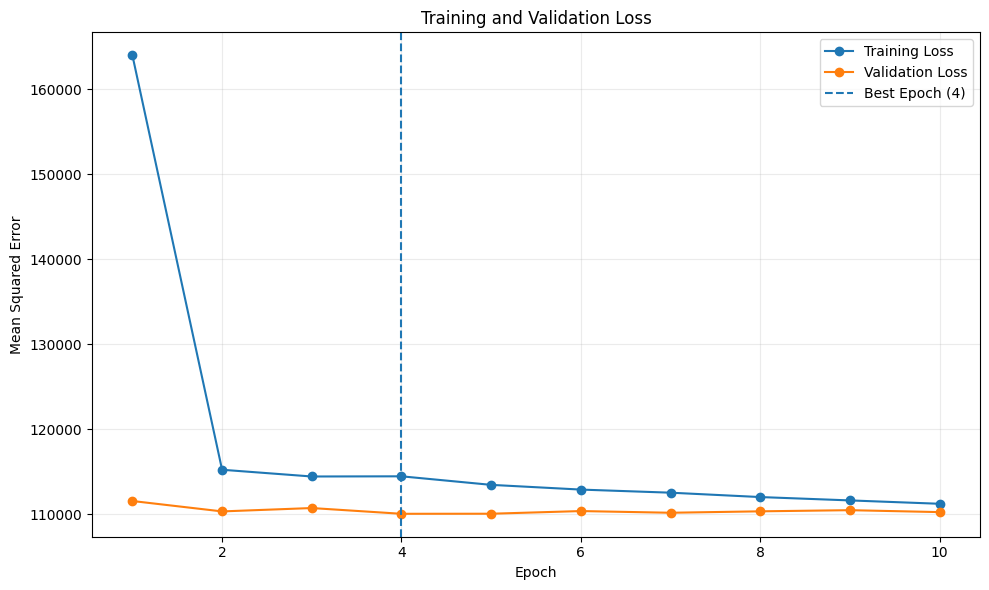

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["loss"],
    marker="o",
    label="Training Loss",
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_epoch})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

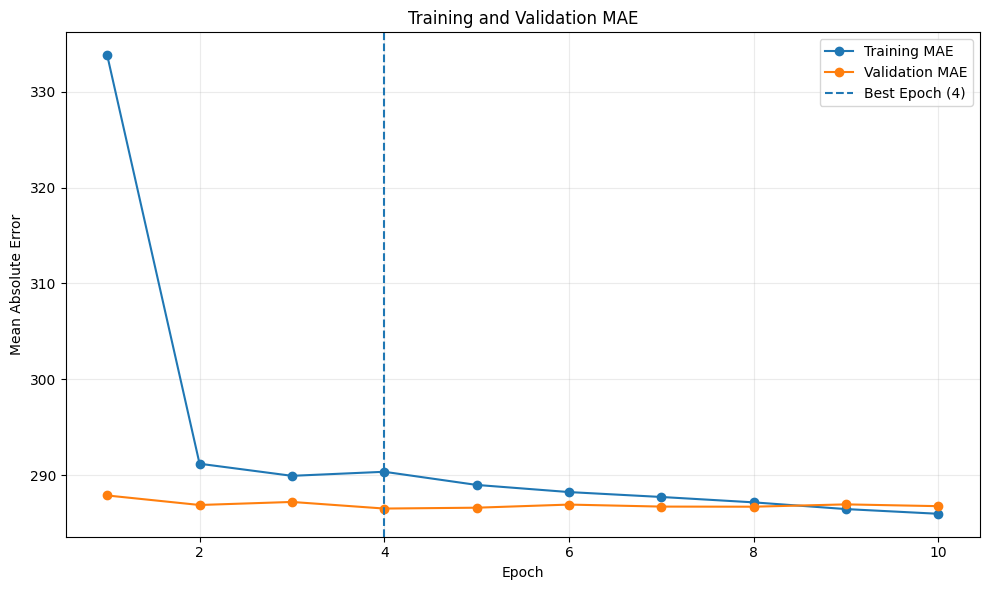

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["mae"],
    marker="o",
    label="Training MAE",
)

ax.plot(
    history_df["epoch"],
    history_df["val_mae"],
    marker="o",
    label="Validation MAE",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_epoch})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Training and Validation MAE")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

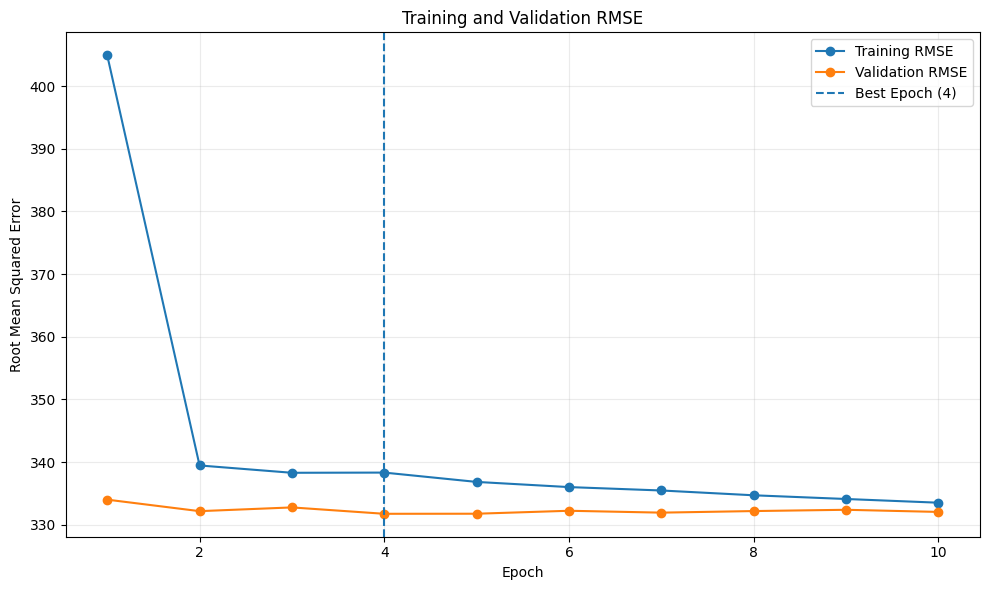

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_df["epoch"],
    history_df["rmse"],
    marker="o",
    label="Training RMSE",
)

ax.plot(
    history_df["epoch"],
    history_df["val_rmse"],
    marker="o",
    label="Validation RMSE",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_epoch})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Root Mean Squared Error")
ax.set_title("Training and Validation RMSE")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


test_predictions = model.predict(
    X_test_processed,
    batch_size=CFG.batch_size,
    verbose=0,
).reshape(-1)

test_metrics = {
    "MAE": mean_absolute_error(y_test, test_predictions),
    "MSE": mean_squared_error(y_test, test_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_predictions)),
    "R²": r2_score(y_test, test_predictions),
}

metrics_frame = (
    pd.Series(test_metrics, name="Deep Neural Network")
    .to_frame()
)

metrics_frame["Value"] = metrics_frame.iloc[:, 0]
metrics_frame = metrics_frame[["Value"]]

display(metrics_frame.round(4))

,Value
MAE,287.3000
MSE,111021.2422
RMSE,333.1985
R²,-0.0087


In [26]:
keras_test_metrics = model.evaluate(
    X_test_processed,
    y_test,
    batch_size=CFG.batch_size,
    verbose=0,
    return_dict=True,
)

print("Keras test evaluation")
print("-" * 30)

for metric_name, metric_value in keras_test_metrics.items():
    print(f"{metric_name:>6}: {metric_value:,.4f}")

Keras test evaluation
------------------------------
  loss: 111,021.2422
   mae: 287.2999
  rmse: 333.1985


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


evaluation_frame = pd.DataFrame({
    "actual": y_test,
    "predicted": test_predictions,
})

evaluation_frame["residual"] = (
    evaluation_frame["actual"] - evaluation_frame["predicted"]
)

evaluation_frame["absolute_error"] = (
    evaluation_frame["residual"].abs()
)

evaluation_frame["squared_error"] = (
    evaluation_frame["residual"] ** 2
)

evaluation_frame["relative_error_pct"] = np.where(
    evaluation_frame["actual"] != 0,
    evaluation_frame["absolute_error"]
    / evaluation_frame["actual"] * 100,
    np.nan,
)

display(evaluation_frame.describe().round(3))

,actual,predicted,residual,absolute_error,squared_error,relative_error_pct
count,19869.000,19869.000,19869.000,19869.000,19869.000,19869.000
mean,621.551,604.273,17.278,287.300,111021.242,98.832
std,331.772,34.289,332.758,168.764,101988.234,167.300
min,50.000,422.485,-942.265,0.003,0.000,0.001
25%,334.000,583.409,-269.055,140.139,19639.018,22.189
50%,617.000,603.557,11.328,286.331,81985.438,39.873
75%,910.000,625.077,305.154,429.545,184509.312,80.730
max,1200.000,1785.265,759.515,942.265,887863.562,1316.988


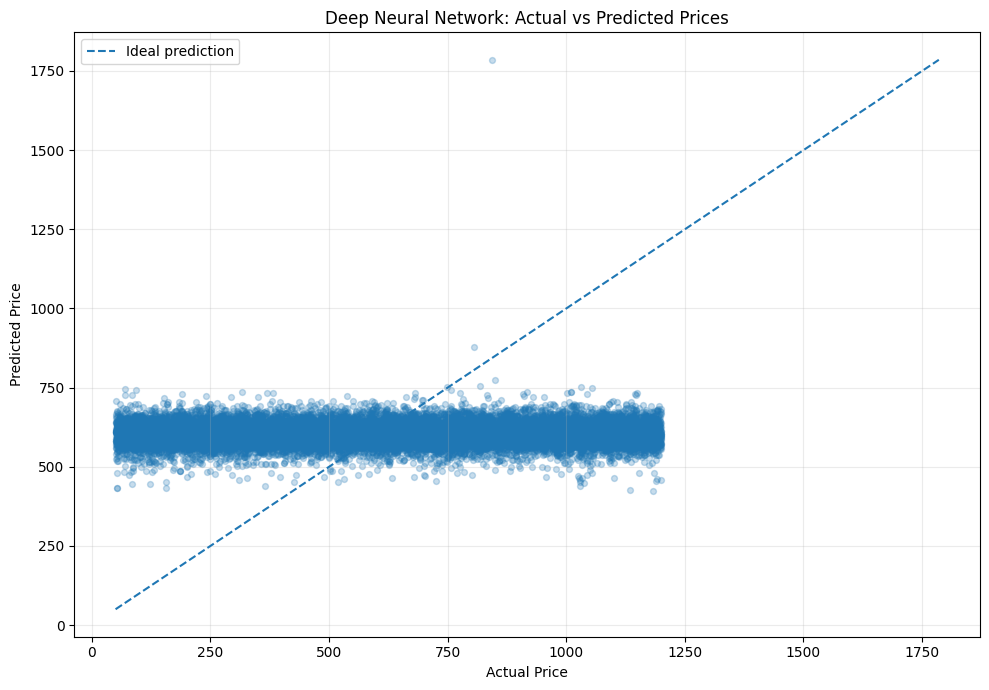

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    evaluation_frame["actual"],
    evaluation_frame["predicted"],
    alpha=0.25,
    s=18,
)

price_min = min(
    evaluation_frame["actual"].min(),
    evaluation_frame["predicted"].min(),
)

price_max = max(
    evaluation_frame["actual"].max(),
    evaluation_frame["predicted"].max(),
)

ax.plot(
    [price_min, price_max],
    [price_min, price_max],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction",
)

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("Deep Neural Network: Actual vs Predicted Prices")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

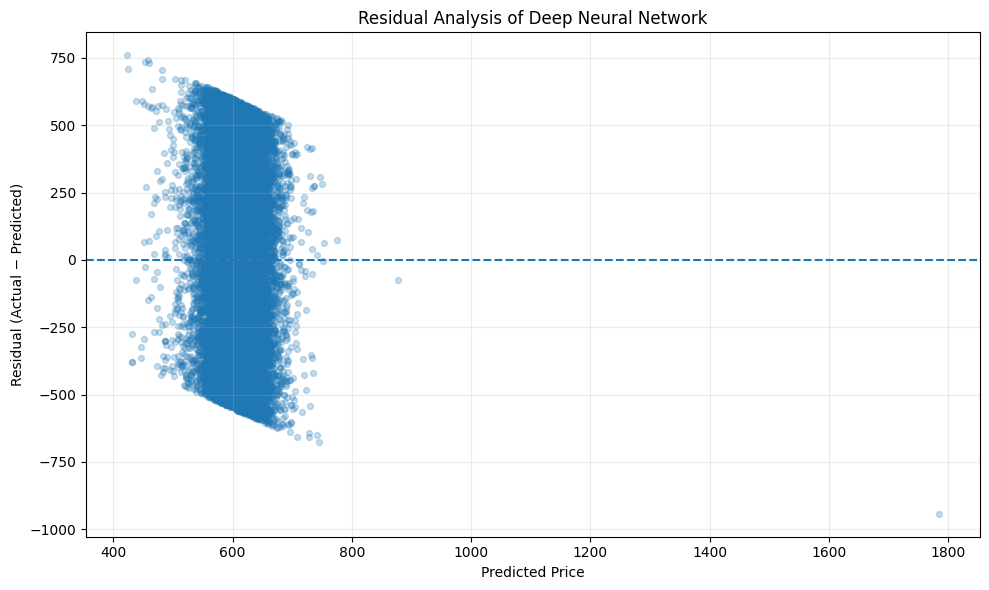

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    evaluation_frame["predicted"],
    evaluation_frame["residual"],
    alpha=0.25,
    s=18,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residual Analysis of Deep Neural Network")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

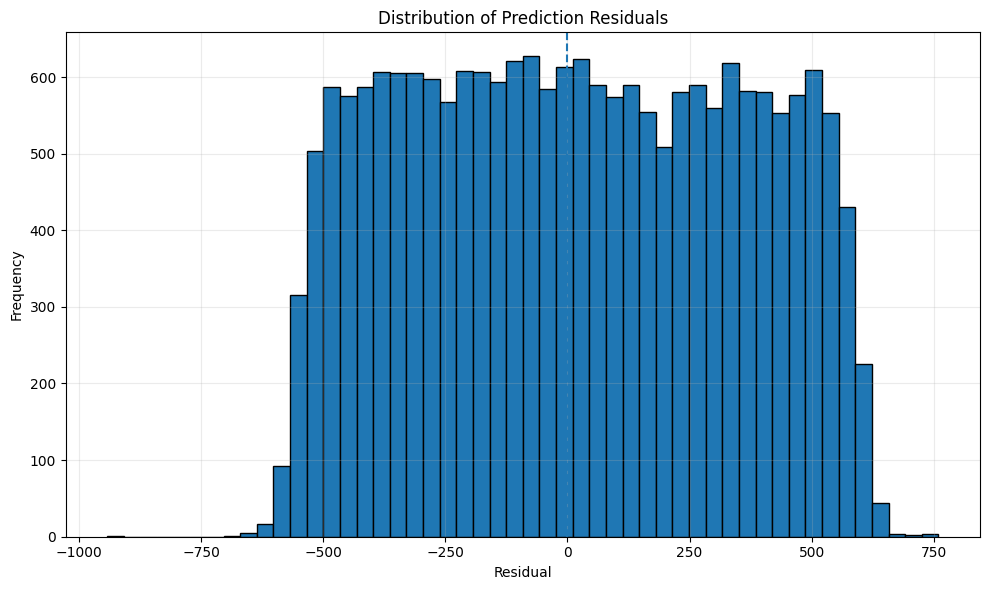

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    evaluation_frame["residual"],
    bins=50,
    edgecolor="black",
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Prediction Residuals")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [31]:
prediction_summary = pd.Series({
    "Actual mean": evaluation_frame["actual"].mean(),
    "Predicted mean": evaluation_frame["predicted"].mean(),
    "Actual median": evaluation_frame["actual"].median(),
    "Predicted median": evaluation_frame["predicted"].median(),
    "Actual std": evaluation_frame["actual"].std(),
    "Predicted std": evaluation_frame["predicted"].std(),
    "Mean residual": evaluation_frame["residual"].mean(),
    "Median absolute error": evaluation_frame["absolute_error"].median(),
    "90th percentile absolute error":
        evaluation_frame["absolute_error"].quantile(0.90),
    "Maximum absolute error":
        evaluation_frame["absolute_error"].max(),
})

display(prediction_summary.to_frame("Value").round(4))

,Value
Actual mean,621.5511
Predicted mean,604.2734
Actual median,617.0000
Predicted median,603.5571
Actual std,331.7720
Predicted std,34.2895
Mean residual,17.2777
Median absolute error,286.3310
90th percentile absolute error,517.7648
Maximum absolute error,942.2651


In [36]:
# ============================================================
# IMPROVED DEEP NEURAL NETWORK
# Airbnb Price Regression
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# 2. Standardize regression target
# ------------------------------------------------------------

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    np.asarray(y_train).reshape(-1, 1)
).ravel()

y_val_scaled = target_scaler.transform(
    np.asarray(y_val).reshape(-1, 1)
).ravel()

# ------------------------------------------------------------
# 3. Define improved architecture
# ------------------------------------------------------------

improved_model = keras.Sequential(
    [
        layers.Input(
            shape=(X_train_processed.shape[1],),
            name="airbnb_features"
        ),

        layers.Dense(
            256,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(1e-4),
            name="dense_256"
        ),
        layers.BatchNormalization(name="bn_256"),
        layers.Activation("relu", name="relu_256"),
        layers.Dropout(0.20, name="dropout_256"),

        layers.Dense(
            128,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(1e-4),
            name="dense_128"
        ),
        layers.BatchNormalization(name="bn_128"),
        layers.Activation("relu", name="relu_128"),
        layers.Dropout(0.15, name="dropout_128"),

        layers.Dense(
            64,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(1e-4),
            name="dense_64"
        ),
        layers.BatchNormalization(name="bn_64"),
        layers.Activation("relu", name="relu_64"),

        layers.Dense(
            32,
            activation="relu",
            kernel_initializer="he_normal",
            name="dense_32"
        ),

        layers.Dense(
            1,
            activation="linear",
            name="price_prediction"
        )
    ],
    name="airbnb_price_regressor_v2"
)

# ------------------------------------------------------------
# 4. Optimizer
# ------------------------------------------------------------

optimizer = keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

# ------------------------------------------------------------
# 5. Compilation
# ------------------------------------------------------------

improved_model.compile(
    optimizer=optimizer,
    loss=keras.losses.Huber(delta=1.0),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

improved_model.summary()

Model: "airbnb_price_regressor_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_256 (Dense)               │ (None, 256)            │        62,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_256 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_256 (Activation)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_128 (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_64 (BatchNormalization)      │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_prediction (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,033 (422.00 KB)

 Trainable params: 107,137 (418.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [37]:
# ============================================================
# TRAIN IMPROVED MODEL
# ============================================================

training_callbacks_v2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath="/content/checkpoints/best_airbnb_price_regressor_v2.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history_v2 = improved_model.fit(
    X_train_processed,
    y_train_scaled,
    validation_data=(X_val_processed, y_val_scaled),
    epochs=40,
    batch_size=256,
    callbacks=training_callbacks_v2,
    verbose=1
)

Epoch 1/40
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5750 - mae: 0.9020 - rmse: 1.0611
Epoch 1: val_loss improved from None to 0.52478, saving model to /content/checkpoints/best_airbnb_price_regressor_v2.keras

Epoch 1: finished saving model to /content/checkpoints/best_airbnb_price_regressor_v2.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.5505 - mae: 0.8831 - rmse: 1.0313 - val_loss: 0.5248 - val_mae: 0.8663 - val_rmse: 1.0023 - learning_rate: 0.0010
Epoch 2/40
279/280 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5250 - mae: 0.8681 - rmse: 1.0070
Epoch 2: val_loss improved from 0.52478 to 0.51311, saving model to /content/checkpoints/best_airbnb_price_regressor_v2.keras

Epoch 2: finished saving model to /content/checkpoints/best_airbnb_price_regressor_v2.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5219 - mae: 0.8673 - rmse: 1.0059 - val_loss: 0.5131 - val_mae: 0.8642 - val_rmse: 0.9995 - learning_rate: 0.0010
Epoch 3/40
278/280 ━━━━━━━━━━━━━━━━━━━

In [38]:
# ============================================================
# RESTORE PREDICTIONS TO ORIGINAL PRICE SCALE
# ============================================================

y_pred_scaled_v2 = improved_model.predict(
    X_test_processed,
    batch_size=1024,
    verbose=0
).ravel()

y_pred_v2 = target_scaler.inverse_transform(
    y_pred_scaled_v2.reshape(-1, 1)
).ravel()

y_pred_v2 = np.clip(
    y_pred_v2,
    a_min=0,
    a_max=None
)

print("Prediction range:")
print(f"Minimum : {y_pred_v2.min():.2f}")
print(f"Maximum : {y_pred_v2.max():.2f}")
print(f"Mean    : {y_pred_v2.mean():.2f}")

Prediction range:
Minimum : 0.00
Maximum : 795.13
Mean    : 624.68


In [39]:
# ============================================================
# IMPROVED MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
mse_v2 = mean_squared_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mse_v2)
r2_v2 = r2_score(y_test, y_pred_v2)

improved_results = {
    "MAE": mae_v2,
    "MSE": mse_v2,
    "RMSE": rmse_v2,
    "R²": r2_v2
}

display(
    pd.DataFrame(improved_results, index=["Improved DNN"])
    .round(4)
)

,MAE,MSE,RMSE,R²
Improved DNN,286.9809,110527.6562,332.457,-0.0042


In [40]:
# ============================================================
# CONSOLIDATED MODEL BENCHMARK
# ============================================================

benchmark = pd.DataFrame.from_dict(
    {
        "Linear Regression": {
            "MAE": 286.93,
            "MSE": 110293.20,
            "RMSE": 332.10,
            "R²": -0.0021,
        },
        "Random Forest": {
            "MAE": 228.65,
            "MSE": 78564.90,
            "RMSE": 280.29,
            "R²": 0.2862,
        },
        "Tuned Random Forest": {
            "MAE": 282.76,
            "MSE": 107074.67,
            "RMSE": 327.22,
            "R²": 0.0272,
        },
        "Baseline DNN": {
            "MAE": test_metrics["MAE"],
            "MSE": test_metrics["MSE"],
            "RMSE": test_metrics["RMSE"],
            "R²": test_metrics["R²"],
        },
        "Improved DNN": {
            "MAE": mae_v2,
            "MSE": mse_v2,
            "RMSE": rmse_v2,
            "R²": r2_v2,
        },
    },
    orient="index",
)

display(benchmark.round(4))

,MAE,MSE,RMSE,R²
Linear Regression,286.9300,110293.2000,332.1000,-0.0021
Random Forest,228.6500,78564.9000,280.2900,0.2862
Tuned Random Forest,282.7600,107074.6700,327.2200,0.0272
Baseline DNN,287.3000,111021.2422,333.1985,-0.0087
Improved DNN,286.9809,110527.6562,332.4570,-0.0042


In [41]:
dnn_delta = pd.Series({
    "MAE change": mae_v2 - test_metrics["MAE"],
    "MSE change": mse_v2 - test_metrics["MSE"],
    "RMSE change": rmse_v2 - test_metrics["RMSE"],
    "R² change": r2_v2 - test_metrics["R²"],
})

dnn_percentage_change = pd.Series({
    "MAE % change":
        (mae_v2 - test_metrics["MAE"])
        / test_metrics["MAE"] * 100,

    "MSE % change":
        (mse_v2 - test_metrics["MSE"])
        / test_metrics["MSE"] * 100,

    "RMSE % change":
        (rmse_v2 - test_metrics["RMSE"])
        / test_metrics["RMSE"] * 100,
})

print("Absolute change")
display(dnn_delta.to_frame("Change").round(6))

print("Percentage change")
display(dnn_percentage_change.to_frame("Change (%)").round(4))

Absolute change


,Change
MAE change,-0.319122
MSE change,-493.585938
RMSE change,-0.741504
R² change,0.004484


Percentage change


,Change (%)
MAE % change,-0.1111
MSE % change,-0.4446
RMSE % change,-0.2225


In [43]:
# ============================================================
# IMPROVED MODEL TRAINING HISTORY
# ============================================================

if "improved_history" in globals():
    training_history = improved_history

elif hasattr(improved_model, "history") and improved_model.history is not None:
    training_history = improved_model.history

else:
    training_history = None


if training_history is None:
    raise RuntimeError(
        "Training history is unavailable in the current runtime. "
        "Please rerun the improved-model training cell."
    )

history_v2_df = pd.DataFrame(training_history.history)
history_v2_df.insert(
    0,
    "epoch",
    np.arange(1, len(history_v2_df) + 1)
)

best_v2_idx = history_v2_df["val_loss"].idxmin()
best_v2_epoch = int(
    history_v2_df.loc[best_v2_idx, "epoch"]
)

print(f"Epochs completed       : {len(history_v2_df)}")
print(f"Best validation epoch : {best_v2_epoch}")
print(
    f"Best validation loss  : "
    f"{history_v2_df.loc[best_v2_idx, 'val_loss']:.6f}"
)
print(
    f"Validation MAE        : "
    f"{history_v2_df.loc[best_v2_idx, 'val_mae']:.6f}"
)
print(
    f"Validation RMSE       : "
    f"{history_v2_df.loc[best_v2_idx, 'val_rmse']:.6f}"
)

Epochs completed       : 23
Best validation epoch : 20
Best validation loss  : 0.469091
Validation MAE        : 0.863716
Validation RMSE       : 1.000644


In [45]:
# ============================================================
# IMPROVED MODEL TRAINING HISTORY
# ============================================================

history_v2_df = pd.DataFrame(improved_history.history)
history_v2_df.insert(
    0,
    "epoch",
    np.arange(1, len(history_v2_df) + 1)
)

best_v2_idx = history_v2_df["val_loss"].idxmin()
best_v2_epoch = int(history_v2_df.loc[best_v2_idx, "epoch"])

print(f"Epochs completed       : {len(history_v2_df)}")
print(f"Best validation epoch : {best_v2_epoch}")
print(
    f"Best validation loss  : "
    f"{history_v2_df.loc[best_v2_idx, 'val_loss']:.6f}"
)
print(
    f"Validation MAE        : "
    f"{history_v2_df.loc[best_v2_idx, 'val_mae']:.6f}"
)
print(
    f"Validation RMSE       : "
    f"{history_v2_df.loc[best_v2_idx, 'val_rmse']:.6f}"
)

Epochs completed       : 8
Best validation epoch : 1
Best validation loss  : 0.469470
Validation MAE        : 0.862214
Validation RMSE       : 0.998670


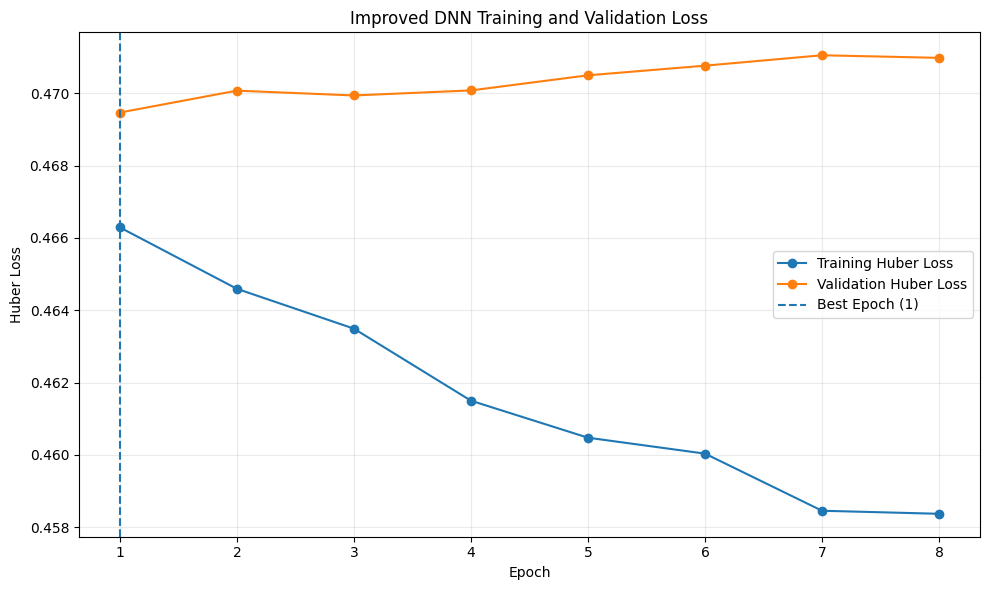

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_v2_df["epoch"],
    history_v2_df["loss"],
    marker="o",
    label="Training Huber Loss",
)

ax.plot(
    history_v2_df["epoch"],
    history_v2_df["val_loss"],
    marker="o",
    label="Validation Huber Loss",
)

ax.axvline(
    best_v2_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_v2_epoch})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.set_title("Improved DNN Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

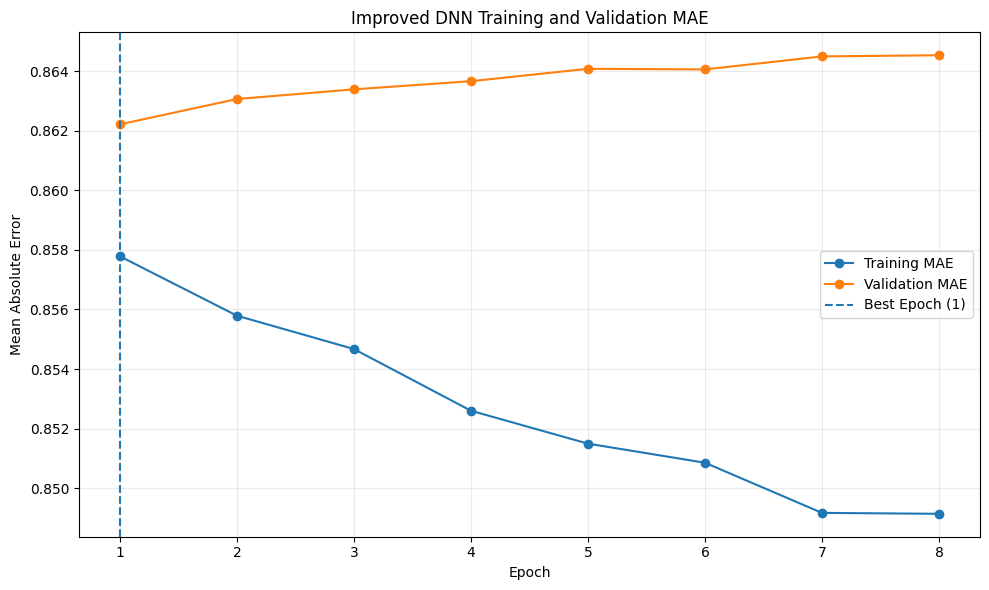

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_v2_df["epoch"],
    history_v2_df["mae"],
    marker="o",
    label="Training MAE",
)

ax.plot(
    history_v2_df["epoch"],
    history_v2_df["val_mae"],
    marker="o",
    label="Validation MAE",
)

ax.axvline(
    best_v2_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_v2_epoch})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Improved DNN Training and Validation MAE")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# PREDICTION DISPERSION DIAGNOSTIC
# ============================================================

prediction_diagnostics = pd.DataFrame(
    {
        "Statistic": [
            "Mean",
            "Median",
            "Standard deviation",
            "Minimum",
            "Maximum",
        ],

        "Actual": [
            y_test.mean(),
            np.median(y_test),
            y_test.std(),
            y_test.min(),
            y_test.max(),
        ],

        "Baseline DNN": [
            test_predictions.mean(),
            np.median(test_predictions),
            test_predictions.std(),
            test_predictions.min(),
            test_predictions.max(),
        ],

        "Improved DNN": [
            y_pred_v2.mean(),
            np.median(y_pred_v2),
            y_pred_v2.std(),
            y_pred_v2.min(),
            y_pred_v2.max(),
        ],
    }
)

display(
    prediction_diagnostics.round(4)
)

,Statistic,Actual,Baseline DNN,Improved DNN
0,Mean,621.551086,604.273376,624.676208
1,Median,617.000000,603.557190,624.762817
2,Standard deviation,331.764099,34.288601,31.953199
3,Minimum,50.000000,422.484802,0.000000
4,Maximum,1200.000000,1785.265259,795.127808


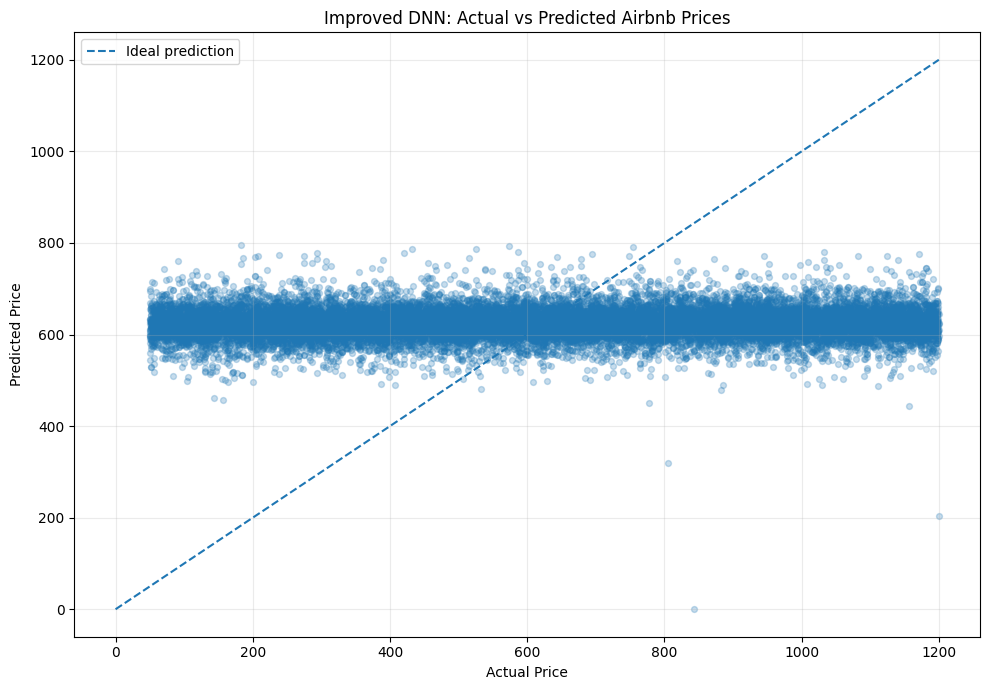

In [49]:
improved_evaluation = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_v2,
})

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    improved_evaluation["actual"],
    improved_evaluation["predicted"],
    alpha=0.25,
    s=18,
)

plot_min = min(
    improved_evaluation["actual"].min(),
    improved_evaluation["predicted"].min(),
)

plot_max = max(
    improved_evaluation["actual"].max(),
    improved_evaluation["predicted"].max(),
)

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction",
)

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title(
    "Improved DNN: Actual vs Predicted Airbnb Prices"
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

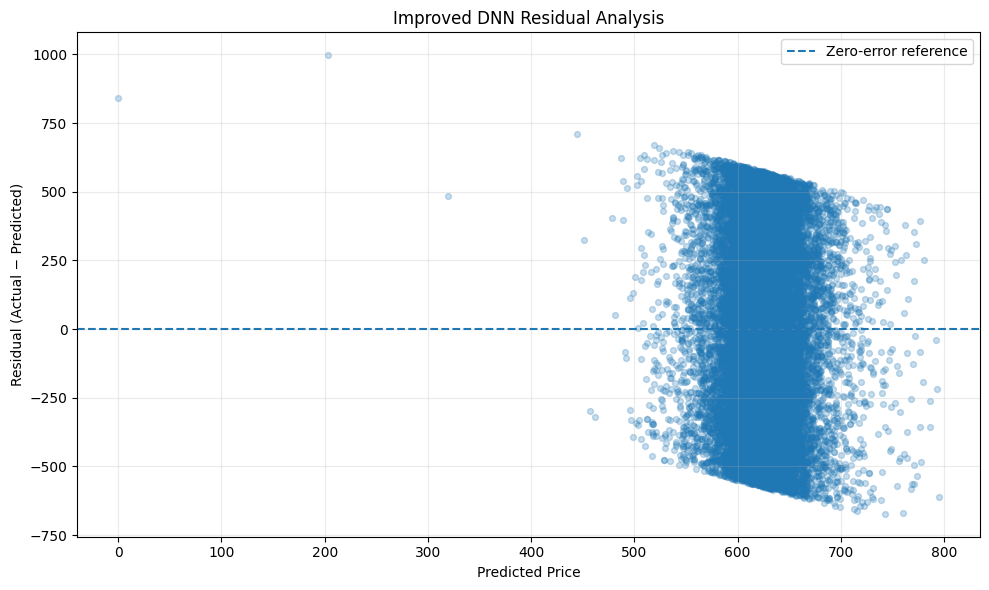

In [50]:
# ============================================================
# IMPROVED DNN RESIDUAL ANALYSIS
# ============================================================

improved_evaluation["residual"] = (
    improved_evaluation["actual"]
    - improved_evaluation["predicted"]
)

improved_evaluation["absolute_error"] = (
    improved_evaluation["residual"].abs()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    improved_evaluation["predicted"],
    improved_evaluation["residual"],
    alpha=0.25,
    s=18,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero-error reference",
)

ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Improved DNN Residual Analysis")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

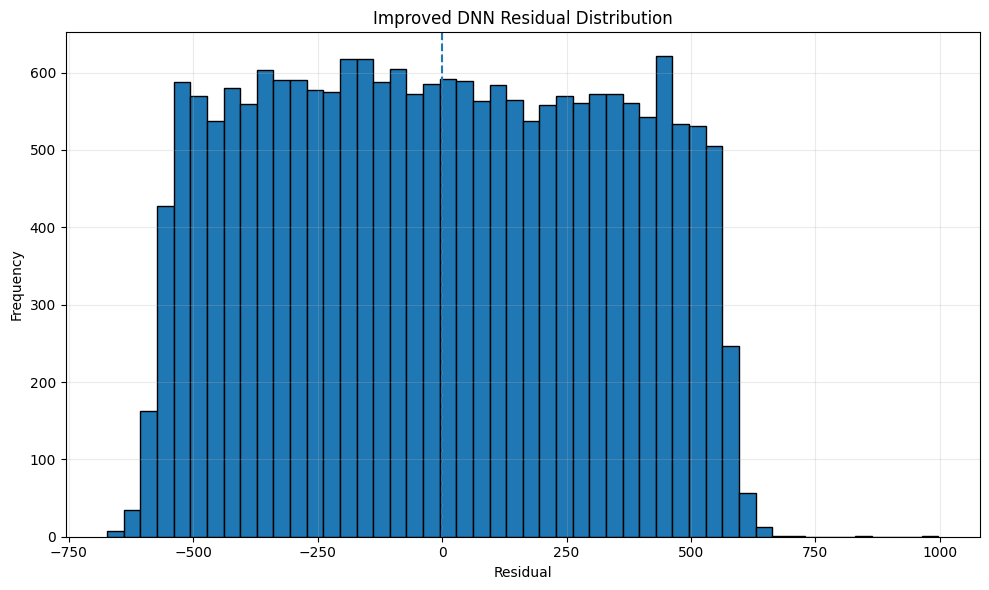

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    improved_evaluation["residual"],
    bins=50,
    edgecolor="black",
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Improved DNN Residual Distribution")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# FINAL MODEL BENCHMARK
# ============================================================

benchmark = pd.DataFrame.from_dict(
    {
        "Linear Regression": {
            "MAE": 286.93,
            "MSE": 110293.20,
            "RMSE": 332.10,
            "R²": -0.0021,
        },
        "Random Forest": {
            "MAE": 228.65,
            "MSE": 78564.90,
            "RMSE": 280.29,
            "R²": 0.2862,
        },
        "Tuned Random Forest": {
            "MAE": 282.76,
            "MSE": 107074.67,
            "RMSE": 327.22,
            "R²": 0.0272,
        },
        "Baseline DNN": {
            "MAE": test_metrics["MAE"],
            "MSE": test_metrics["MSE"],
            "RMSE": test_metrics["RMSE"],
            "R²": test_metrics["R²"],
        },
        "Improved DNN": {
            "MAE": mae_v2,
            "MSE": mse_v2,
            "RMSE": rmse_v2,
            "R²": r2_v2,
        },
    },
    orient="index",
)

display(benchmark.round(4))

,MAE,MSE,RMSE,R²
Linear Regression,286.9300,110293.2000,332.1000,-0.0021
Random Forest,228.6500,78564.9000,280.2900,0.2862
Tuned Random Forest,282.7600,107074.6700,327.2200,0.0272
Baseline DNN,287.3000,111021.2422,333.1985,-0.0087
Improved DNN,286.9809,110527.6562,332.4570,-0.0042


In [53]:
prediction_diagnostics = pd.DataFrame(
    {
        "Statistic": [
            "Mean",
            "Median",
            "Standard deviation",
            "Minimum",
            "Maximum",
        ],
        "Actual": [
            y_test.mean(),
            np.median(y_test),
            y_test.std(),
            y_test.min(),
            y_test.max(),
        ],
        "Baseline DNN": [
            test_predictions.mean(),
            np.median(test_predictions),
            test_predictions.std(),
            test_predictions.min(),
            test_predictions.max(),
        ],
        "Improved DNN": [
            y_pred_v2.mean(),
            np.median(y_pred_v2),
            y_pred_v2.std(),
            y_pred_v2.min(),
            y_pred_v2.max(),
        ],
    }
)

display(prediction_diagnostics.round(4))

,Statistic,Actual,Baseline DNN,Improved DNN
0,Mean,621.551086,604.273376,624.676208
1,Median,617.000000,603.557190,624.762817
2,Standard deviation,331.764099,34.288601,31.953199
3,Minimum,50.000000,422.484802,0.000000
4,Maximum,1200.000000,1785.265259,795.127808


In [55]:
# ============================================================
# SAVE ARTIFACTS
# ============================================================

MODEL_DIR = Path("/content/week5_artifacts")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

improved_model.save(
    MODEL_DIR / "airbnb_price_regressor_v2.keras"
)

benchmark.to_csv(
    MODEL_DIR / "model_benchmark.csv"
)

history_v2_df.to_csv(
    MODEL_DIR / "training_history_v2.csv",
    index=False
)

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [56]:
# ============================================================
# PREDICTION DISPERSION RATIO
# ============================================================

actual_std = np.std(y_test)

baseline_std = np.std(test_predictions)

improved_std = np.std(y_pred_v2)

dispersion_analysis = pd.DataFrame(
    {
        "Model": [
            "Actual target",
            "Baseline DNN",
            "Improved DNN",
        ],
        "Standard deviation": [
            actual_std,
            baseline_std,
            improved_std,
        ],
        "Relative to actual (%)": [
            100.0,
            (baseline_std / actual_std) * 100,
            (improved_std / actual_std) * 100,
        ],
    }
)

display(
    dispersion_analysis.round(4)
)

,Model,Standard deviation,Relative to actual (%)
0,Actual target,331.764099,100.0000
1,Baseline DNN,34.288601,10.3352
2,Improved DNN,31.953199,9.6313


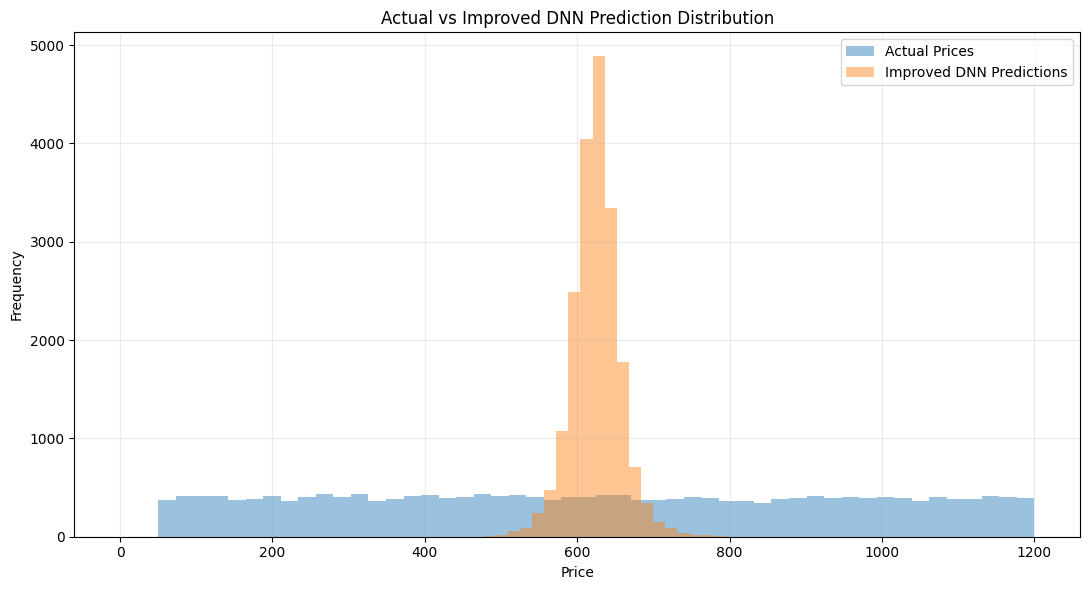

In [57]:
# ============================================================
# ACTUAL VS DNN PREDICTION DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    y_test,
    bins=50,
    alpha=0.45,
    label="Actual Prices",
)

ax.hist(
    y_pred_v2,
    bins=50,
    alpha=0.45,
    label="Improved DNN Predictions",
)

ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
ax.set_title(
    "Actual vs Improved DNN Prediction Distribution"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# FINAL ERROR STATISTICS
# ============================================================

final_residual_stats = pd.Series(
    {
        "Mean residual":
            improved_evaluation["residual"].mean(),

        "Median residual":
            improved_evaluation["residual"].median(),

        "Residual standard deviation":
            improved_evaluation["residual"].std(),

        "Median absolute error":
            improved_evaluation["absolute_error"].median(),

        "90th percentile absolute error":
            improved_evaluation["absolute_error"].quantile(0.90),

        "Maximum absolute error":
            improved_evaluation["absolute_error"].max(),
    },
    name="Value",
)

display(
    final_residual_stats.to_frame().round(4)
)

,Value
Mean residual,-3.1250
Median residual,-8.1506
Residual standard deviation,332.4507
Median absolute error,286.0445
90th percentile absolute error,519.1246
Maximum absolute error,997.0112


In [59]:
# ============================================================
# FINAL WEEK 5 EXPERIMENT SUMMARY
# ============================================================

final_results = pd.DataFrame(
    {
        "Metric": ["MAE", "MSE", "RMSE", "R²"],
        "Linear Regression": [
            286.93,
            110293.20,
            332.10,
            -0.0021,
        ],
        "Random Forest": [
            228.65,
            78564.90,
            280.29,
            0.2862,
        ],
        "Tuned Random Forest": [
            282.76,
            107074.67,
            327.22,
            0.0272,
        ],
        "Baseline DNN": [
            test_metrics["MAE"],
            test_metrics["MSE"],
            test_metrics["RMSE"],
            test_metrics["R²"],
        ],
        "Improved DNN": [
            mae_v2,
            mse_v2,
            rmse_v2,
            r2_v2,
        ],
    }
)

display(
    final_results.set_index("Metric").round(4)
)

,Linear Regression,Random Forest,Tuned Random Forest,Baseline DNN,Improved DNN
Metric,,,,,
MAE,286.9300,228.6500,282.7600,287.3000,286.9809
MSE,110293.2000,78564.9000,107074.6700,111021.2422,110527.6562
RMSE,332.1000,280.2900,327.2200,333.1985,332.4570
R²,-0.0021,0.2862,0.0272,-0.0087,-0.0042


In [60]:
# ============================================================
# BASELINE VS IMPROVED DNN
# ============================================================

dnn_comparison = pd.DataFrame(
    {
        "Baseline DNN": [
            test_metrics["MAE"],
            test_metrics["MSE"],
            test_metrics["RMSE"],
            test_metrics["R²"],
        ],
        "Improved DNN": [
            mae_v2,
            mse_v2,
            rmse_v2,
            r2_v2,
        ],
    },
    index=["MAE", "MSE", "RMSE", "R²"],
)

dnn_comparison["Absolute Change"] = (
    dnn_comparison["Improved DNN"]
    - dnn_comparison["Baseline DNN"]
)

display(dnn_comparison.round(4))

,Baseline DNN,Improved DNN,Absolute Change
MAE,287.3000,286.9809,-0.3191
MSE,111021.2422,110527.6562,-493.5859
RMSE,333.1985,332.4570,-0.7415
R²,-0.0087,-0.0042,0.0045


In [61]:
# ============================================================
# FINAL DIAGNOSTIC SUMMARY
# ============================================================

diagnostic_summary = pd.DataFrame(
    {
        "Actual Target": [
            y_test.mean(),
            y_test.std(),
            y_test.min(),
            y_test.max(),
        ],
        "Baseline DNN": [
            test_predictions.mean(),
            test_predictions.std(),
            test_predictions.min(),
            test_predictions.max(),
        ],
        "Improved DNN": [
            y_pred_v2.mean(),
            y_pred_v2.std(),
            y_pred_v2.min(),
            y_pred_v2.max(),
        ],
    },
    index=[
        "Mean",
        "Standard deviation",
        "Minimum",
        "Maximum",
    ],
)

display(diagnostic_summary.round(4))

,Actual Target,Baseline DNN,Improved DNN
Mean,621.551086,604.273376,624.676208
Standard deviation,331.764099,34.288601,31.953199
Minimum,50.000000,422.484802,0.000000
Maximum,1200.000000,1785.265259,795.127808


In [62]:
# ============================================================
# WEEK 5 REPORT ARTIFACTS
# ============================================================

REPORT_DIR = Path("/content/week5_artifacts")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

final_results.to_csv(
    REPORT_DIR / "final_model_comparison.csv",
    index=False,
)

dnn_comparison.to_csv(
    REPORT_DIR / "dnn_improvement_analysis.csv"
)

diagnostic_summary.to_csv(
    REPORT_DIR / "prediction_diagnostics.csv"
)

history_v2_df.to_csv(
    REPORT_DIR / "improved_training_history.csv",
    index=False
)

improved_model.save(
    REPORT_DIR / "final_airbnb_dnn.keras"
)

print(f"Week 5 artifacts stored in: {REPORT_DIR}")

Week 5 artifacts stored in: /content/week5_artifacts
